In [16]:
import os
import numpy as np
import pandas as pd

# ============================================================
# 0) 設定
# ============================================================
NPZ_PATH = "dataset_irregular.npz"
L_GRID   = 256
SEED     = 0
N_BASE   = 120     # 基準波形に使う学習サイクル数（任意に変更）
DEN_EPS  = 1e-6    # NWの分母が小さい点を欠損扱いにする閾値

rng = np.random.default_rng(SEED)

# ============================================================
# 1) 読み込み（ユーザー提示の形式）
# ============================================================
d = np.load(NPZ_PATH, allow_pickle=True)
train_list = d["train_list"].tolist()
test_list  = d["test_list"].tolist()

def group_by_cycle(sample_list):
    """
    sample_list を cycle_id ごとにまとめて dict にする
    dict[cid] = (deg_array, y_array, label)
    """
    arr = np.asarray(sample_list, dtype=object)
    cid = arr[:,0].astype(int)
    deg = arr[:,1].astype(float)
    y   = arr[:,2].astype(float)
    lab = arr[:,3].astype(int)

    order = np.lexsort((deg, cid))
    cid, deg, y, lab = cid[order], deg[order], y[order], lab[order]

    cycles = {}
    start = 0
    while start < len(cid):
        c = int(cid[start])
        end = start
        while end < len(cid) and int(cid[end]) == c:
            end += 1
        cycles[c] = (deg[start:end], y[start:end], int(lab[start]))
        start = end
    return cycles

train_cycles = group_by_cycle(train_list)
test_cycles  = group_by_cycle(test_list)


In [17]:

# ============================================================
# 2) 高速NW（円環：ビン化 + FFT円環畳み込み）
# ============================================================
def bin_sum_on_circle(deg, y, Lbin):
    deg = np.asarray(deg, float)
    y   = np.asarray(y, float)
    idx = np.floor(deg / 360.0 * Lbin).astype(int)
    idx = np.clip(idx, 0, Lbin-1)
    num = np.zeros(Lbin, dtype=float)
    den = np.zeros(Lbin, dtype=float)
    np.add.at(num, idx, y)
    np.add.at(den, idx, 1.0)
    return num, den

def gaussian_kernel_on_circle(Lbin, h_deg):
    delta = 360.0 / Lbin
    k = np.arange(Lbin, dtype=float)
    kdist = np.minimum(k, Lbin - k)     # 円環距離（ビン単位）
    d_deg = kdist * delta
    ker = np.exp(-0.5 * (d_deg / h_deg)**2)
    ker = ker / (ker.sum() + 1e-12)     # 正規化
    return ker

def estimate_h_deg_from_deg(deg, Lbin):
    """
    h_deg を手で決めたくない場合の自動推奨値
    - 角度差分（円環）の中央値 med をとって 2*med を帯域にする
    - 最低でも 1ビン幅 (360/Lbin) は確保
    """
    deg = np.sort(np.asarray(deg, float))
    if len(deg) < 3:
        return 360.0 / Lbin
    dif  = np.diff(deg)
    wrap = (deg[0] + 360.0) - deg[-1]
    dif  = np.concatenate([dif, [wrap]])
    med  = float(np.median(dif))
    return float(max(360.0 / Lbin, 2.0 * med))

def nw_fast_on_circle(deg, y, Lbin, h_deg=None, den_eps=DEN_EPS):
    num_bin, den_bin = bin_sum_on_circle(deg, y, Lbin)
    if h_deg is None:
        h_deg = estimate_h_deg_from_deg(deg, Lbin)
    ker = gaussian_kernel_on_circle(Lbin, h_deg)

    F_num = np.fft.fft(num_bin)
    F_den = np.fft.fft(den_bin)
    F_ker = np.fft.fft(ker)

    num_s = np.fft.ifft(F_num * F_ker).real
    den_s = np.fft.ifft(F_den * F_ker).real

    x = np.full(Lbin, np.nan, float)
    m = den_s > den_eps
    x[m] = num_s[m] / den_s[m]
    return x, m.astype(np.int8), den_s, float(h_deg)

# ============================================================
# 3) 基準波形（参照波形）の作成：学習サイクルをN_BASE本選ぶ → 点を連結 → NW
# ============================================================
train_ids = np.array(sorted(train_cycles.keys()), dtype=int)
rng.shuffle(train_ids)
base_ids = train_ids[:min(N_BASE, len(train_ids))]

deg_ref = np.concatenate([train_cycles[c][0] for c in base_ids])
y_ref   = np.concatenate([train_cycles[c][1] for c in base_ids])

ref_grid, ref_m, ref_den, h_deg_ref = nw_fast_on_circle(deg_ref, y_ref, L_GRID, h_deg=None)

# ============================================================
# 4) 位相シフト推定（FFT相関：欠損対応の重み付き相関）
#   shift_bin = 「x に roll(shift_bin) を適用すると ref に最も合う」定義
# ============================================================
def estimate_phase_shift_by_weighted_corr_fft(x, ref, min_overlap=64):
    x   = np.asarray(x, float)
    ref = np.asarray(ref, float)

    w = np.isfinite(x).astype(float)
    v = np.isfinite(ref).astype(float)

    x0 = np.nan_to_num(x,   nan=0.0)
    r0 = np.nan_to_num(ref, nan=0.0)

    def cc(a, b):
        # circular cross-correlation: ifft(conj(fft(a))*fft(b))
        return np.fft.ifft(np.conj(np.fft.fft(a)) * np.fft.fft(b)).real

    overlap = cc(w, v)            # sum w_shift * v
    sum_x   = cc(x0, v)           # sum x_shift * v
    sum_x2  = cc(x0*x0, v)        # sum x_shift^2 * v
    sum_xr  = cc(x0, r0*v)        # sum x_shift * (ref*v)

    Nv = v.sum()
    if Nv < 2:
        return 0, np.full(len(x), -np.inf)

    mean_r = (r0*v).sum() / Nv
    var_r  = ( (r0*r0*v).sum() / Nv ) - mean_r**2
    var_r  = max(var_r, 1e-12)

    corr = np.full(len(x), -np.inf, float)
    ok = overlap >= float(min_overlap)
    if np.any(ok):
        mx  = sum_x[ok] / overlap[ok]
        vx  = (sum_x2[ok] / overlap[ok]) - mx**2
        vx  = np.maximum(vx, 1e-12)
        cov = (sum_xr[ok] / overlap[ok]) - mx*mean_r
        corr[ok] = cov / np.sqrt(vx * var_r)

    s = int(np.nanargmax(corr))
    return s, corr

# ============================================================
# 5) 形状差・スパイク・周波数差に使う補助
# ============================================================
def zscore_with_mask(x, m):
    x = np.asarray(x, float)
    m = np.asarray(m, bool)
    if m.sum() < 3:
        return np.full_like(x, np.nan), np.nan, np.nan
    mu = float(np.mean(x[m]))
    sd = float(np.std(x[m]))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1e-12
    z = (x - mu) / sd
    z[~m] = np.nan
    return z, mu, sd

def fft_band_power_ratios(x, bands, exclude_dc=True):
    x0 = np.nan_to_num(np.asarray(x, float), nan=0.0)
    F  = np.fft.rfft(x0)
    P  = (F.real*F.real + F.imag*F.imag)  # power
    if exclude_dc and len(P) > 0:
        P = P.copy()
        P[0] = 0.0
    total = float(P.sum()) + 1e-12
    out = {}
    for name, (k0, k1) in bands.items():
        k0 = max(0, int(k0))
        k1 = min(len(P)-1, int(k1))
        out[name] = float(P[k0:k1+1].sum() / total)
    return out, P

def cosine_sim(a, b, eps=1e-12):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return np.nan
    return float(a.dot(b) / (na*nb))

BANDS = {
    "low_1_3": (1, 3),
    "mid_4_16": (4, 16),
    "high_17_64": (17, 64),
    "ultra_65_128": (65, 128),
}

# ============================================================
# 6) 1サイクルの特徴量
# ============================================================
def features_one_cycle(deg, y, label, ref_grid, h_deg_shared):
    # 等間隔化
    x_grid, m, den_s, h_used = nw_fast_on_circle(deg, y, L_GRID, h_deg=h_deg_shared)

    # 位相（横ずれ）
    shift_bin, corr = estimate_phase_shift_by_weighted_corr_fft(x_grid, ref_grid, min_overlap=2)
    shift_deg = shift_bin * 360.0 / L_GRID

    # 位置合わせ（x を roll して ref に合わせる）
    x_al = np.roll(x_grid, shift_bin)
    ok   = np.isfinite(x_al) & np.isfinite(ref_grid)
    n_ok = int(ok.sum())

    # ①上下シフト（平均との差：オフセット）
    offset_mean = float(np.mean((x_al - ref_grid)[ok])) if n_ok >= 3 else np.nan

    # ③形状変化（標準化後の RMS 差）
    zx, mu_x, sd_x = zscore_with_mask(x_al, ok)
    zr, mu_r, sd_r = zscore_with_mask(ref_grid, ok)
    shape_rms = float(np.sqrt(np.mean((zx[ok] - zr[ok])**2))) if n_ok >= 3 else np.nan

    # ⑤スパイク（局所的な最大差）
    spike_abs  = float(np.nanmax(np.abs((x_al - ref_grid) - offset_mean))) if np.isfinite(offset_mean) else np.nan
    spike_zmax = float(np.nanmax(np.abs(zx - zr))) if n_ok >= 3 else np.nan

    # ④周波数成分の変化（標準化後FFTの帯域パワー比の差 + スペクトル類似度）
    band_x, P_x = fft_band_power_ratios(zx, BANDS)
    band_r, P_r = fft_band_power_ratios(zr, BANDS)

    out = {
        "cycle_id": None,
        "label": int(label),

        # 波形全体の平均（絶対値としての平均）
        "mean": float(np.nanmean(x_grid)),

        # ①上下シフト（参照との差分としての平均）
        "offset_mean": offset_mean,

        # ②横ずれ（位相）
        "phase_shift_bin": int(shift_bin),
        "phase_shift_deg": float(shift_deg),
        "phase_corr_max": float(np.nanmax(corr)),

        # ③形状差
        "shape_rms": shape_rms,

        # ⑤スパイク
        "spike_abs": spike_abs,
        "spike_zmax": spike_zmax,

        # ④周波数差（スペクトル）
        "spec_cosine": cosine_sim(P_x[1:], P_r[1:]),
    }
    for k in BANDS.keys():
        out[f"band_{k}_x"]    = band_x[k]
        out[f"band_{k}_ref"]  = band_r[k]
        out[f"band_{k}_diff"] = band_x[k] - band_r[k]
    return out


In [18]:

# ============================================================
# 7) 全サイクルに適用して DataFrame 化
#   方針：h_deg を参照波形作成時に推定した値で「全サイクル共通」にする（挙動が安定）
# ============================================================
def build_features_df(cycles_dict, ref_grid, h_deg_shared):
    rows = []
    for cid, (deg, y, lab) in cycles_dict.items():
        f = features_one_cycle(deg, y, lab, ref_grid, h_deg_shared=h_deg_shared)
        f["cycle_id"] = int(cid)
        rows.append(f)
    return pd.DataFrame(rows).sort_values("cycle_id").reset_index(drop=True)

train_df = build_features_df(train_cycles, ref_grid, h_deg_shared=h_deg_ref)
test_df  = build_features_df(test_cycles,  ref_grid, h_deg_shared=h_deg_ref)

print("h_deg_ref:", h_deg_ref)
print("train_df shape:", train_df.shape, "test_df shape:", test_df.shape)

# 必要なら保存
# train_df.to_csv("train_features.csv", index=False)
# test_df.to_csv("test_features.csv", index=False)

test_df

h_deg_ref: 1.40625
train_df shape: (700, 23) test_df shape: (1020, 23)


,cycle_id,label,mean,offset_mean,phase_shift_bin,phase_shift_deg,phase_corr_max,shape_rms,spike_abs,spike_zmax,...,band_low_1_3_diff,band_mid_4_16_x,band_mid_4_16_ref,band_mid_4_16_diff,band_high_17_64_x,band_high_17_64_ref,band_high_17_64_diff,band_ultra_65_128_x,band_ultra_65_128_ref,band_ultra_65_128_diff
0,0,0,-0.002814,-0.002041,0,0.0,0.998363,0.057213,0.129786,0.171186,...,-0.004586,0.021948,0.019115,0.002833,0.001687,0.000019,0.001669,0.000085,9.866879e-07,0.000084
1,1,0,0.004114,0.004887,0,0.0,0.997840,0.065733,0.126950,0.168903,...,-0.005411,0.022112,0.019115,0.002997,0.002346,0.000019,0.002327,0.000088,9.866879e-07,0.000087
2,2,0,0.001363,0.002135,0,0.0,0.998349,0.057458,0.121403,0.163961,...,-0.006075,0.023201,0.019115,0.004086,0.001941,0.000019,0.001923,0.000067,9.866879e-07,0.000066
3,3,0,-0.007017,-0.006245,0,0.0,0.998425,0.056122,0.137155,0.173377,...,-0.002803,0.020289,0.019115,0.001174,0.001576,0.000019,0.001557,0.000073,9.866879e-07,0.000072
4,4,0,-0.001540,-0.000768,0,0.0,0.998396,0.056637,0.127188,0.169755,...,-0.003929,0.020990,0.019115,0.001875,0.002007,0.000019,0.001988,0.000067,9.866879e-07,0.000066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,1015,0,-0.013125,-0.012352,0,0.0,0.998103,0.061596,0.163577,0.218846,...,-0.004076,0.020937,0.019115,0.001822,0.002201,0.000019,0.002183,0.000072,9.866879e-07,0.000071
1016,1016,0,-0.002295,-0.001523,0,0.0,0.998680,0.051390,0.105934,0.140304,...,-0.005043,0.022534,0.019115,0.003418,0.001574,0.000019,0.001556,0.000069,9.866879e-07,0.000068
1017,1017,0,-0.010607,-0.009835,0,0.0,0.998269,0.058843,0.120331,0.156138,...,-0.003476,0.020596,0.019115,0.001481,0.001935,0.000019,0.001916,0.000080,9.866879e-07,0.000079
1018,1018,0,-0.005359,-0.004587,0,0.0,0.998163,0.060614,0.150202,0.196954,...,-0.004357,0.021437,0.019115,0.002322,0.001957,0.000019,0.001939,0.000097,9.866879e-07,0.000096


In [19]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# 0) 特徴量を分ける（A:誤報低減）
# -----------------------------
band_diff_cols = [c for c in train_df.columns if c.startswith("band_") and c.endswith("_diff")]

# PCAに入れる：形状＋周波数だけ
pca_cols = []
if "shape_rms" in train_df.columns: pca_cols.append("shape_rms")
pca_cols += band_diff_cols
if "spec_cosine" in train_df.columns:
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df["spec_dist"] = 1.0 - train_df["spec_cosine"]
    test_df["spec_dist"]  = 1.0 - test_df["spec_cosine"]
    pca_cols.append("spec_dist")

# 別監視（診断用）
diag_offset_cols = [c for c in ["offset_mean", "mean"] if c in train_df.columns]

def wrap_deg180(deg):
    return ((deg + 180.0) % 360.0) - 180.0

if "phase_shift_deg" in train_df.columns:
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df["phase_shift_180"] = wrap_deg180(train_df["phase_shift_deg"].to_numpy())
    test_df["phase_shift_180"]  = wrap_deg180(test_df["phase_shift_deg"].to_numpy())
diag_phase_cols = [c for c in ["phase_shift_180", "phase_corr_max"] if c in train_df.columns]

diag_spike_cols = [c for c in ["spike_abs", "spike_zmax"] if c in train_df.columns]

# -----------------------------
# 1) PCA（欠損→標準化→PCA）
# -----------------------------
Xtr = train_df[pca_cols].to_numpy()
Xte = test_df[pca_cols].to_numpy()

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

Xtr_i = imputer.fit_transform(Xtr)
Xte_i = imputer.transform(Xte)

Xtr_z = scaler.fit_transform(Xtr_i)
Xte_z = scaler.transform(Xte_i)

pca_full = PCA(svd_solver="full", random_state=0).fit(Xtr_z)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k_score = int(np.searchsorted(cum, 0.90) + 1)   # スコア計算用（1でもOK）
k_score = max(1, k_score)

pca = PCA(n_components=k_score, svd_solver="full", random_state=0).fit(Xtr_z)
Ttr = pca.transform(Xtr_z)
Tte = pca.transform(Xte_z)

lam = pca.explained_variance_
T2_tr = np.sum((Ttr**2) / (lam[None, :] + 1e-12), axis=1)
T2_te = np.sum((Tte**2) / (lam[None, :] + 1e-12), axis=1)

Xtr_hat = pca.inverse_transform(Ttr)
Xte_hat = pca.inverse_transform(Tte)
Q_tr = np.sum((Xtr_z - Xtr_hat)**2, axis=1)
Q_te = np.sum((Xte_z - Xte_hat)**2, axis=1)

ALPHA = 0.99
thr_T2 = float(np.quantile(T2_tr, ALPHA))
thr_Q  = float(np.quantile(Q_tr,  ALPHA))

# -----------------------------
# 2) 診断用スコア（誤報低減のため “アラームに直結させない” 前提）
# -----------------------------
df_tr = train_df[["cycle_id","label"]].copy()
df_te = test_df[["cycle_id","label"]].copy()
df_tr["T2"], df_tr["Q"] = T2_tr, Q_tr
df_te["T2"], df_te["Q"] = T2_te, Q_te

for c in diag_offset_cols + diag_phase_cols + diag_spike_cols:
    df_te[c] = test_df[c].to_numpy()

# ここでアラーム判定はまず Q（またはT2）だけにするのがA向き
df_te["alarm"] = (df_te["Q"] > thr_Q)  # まずこれで誤報率を見る

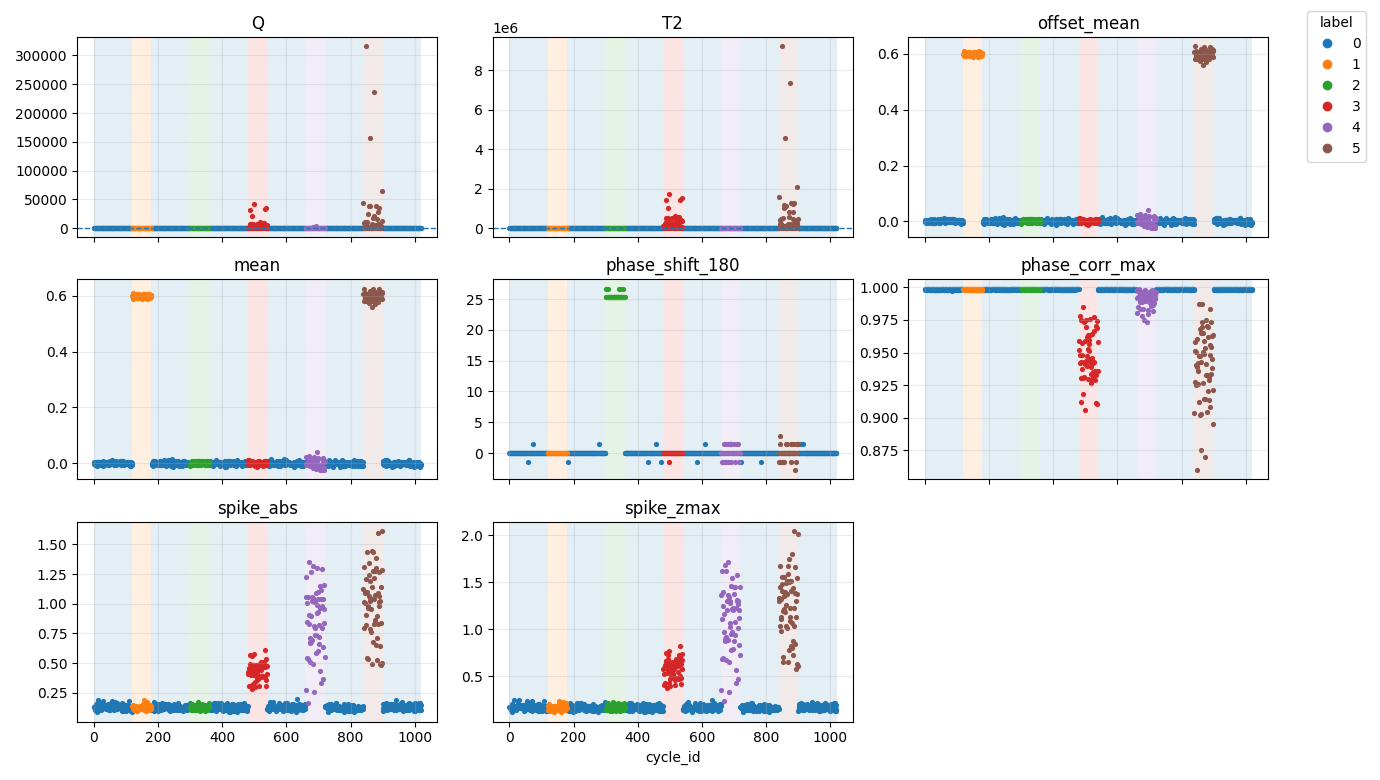

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def _label_colors(labels, cmap_name=None):
    u = np.unique(labels)
    if cmap_name is None:
        cmap_name = "tab20" if len(u) > 10 else "tab10"
    cmap = plt.get_cmap(cmap_name)
    colors = {lab: cmap(i % cmap.N) for i, lab in enumerate(u)}
    return colors

def _add_label_background(ax, x, lab, colors, alpha=0.10):
    # x は昇順前提（呼び出し側で sort 済み）
    n = len(x)
    if n == 0:
        return
    start = 0
    cur = lab[0]
    for i in range(1, n + 1):
        if i == n or lab[i] != cur:
            x0 = x[start]
            x1 = x[i - 1]
            # 同じラベル区間の背景を塗る（少しだけ左右に広げる）
            dx = (x[1] - x[0]) if n >= 2 else 1.0
            ax.axvspan(x0 - 0.5 * dx, x1 + 0.5 * dx, color=colors[cur], alpha=alpha, lw=0)
            if i < n:
                start = i
                cur = lab[i]

def plot_scores_tiled(
    df,
    score_cols=None,
    x_col="cycle_id",
    label_col="label",
    thresholds=None,   # 例: {"Q": thr_Q, "T2": thr_T2}
    ncols=3,
    figsize_per_ax=(4.6, 2.6),
    bg_alpha=0.10,
    point_size=12,
):
    d = df.copy()

    # 並び順（背景の区間塗りに必要）
    if x_col in d.columns:
        d = d.sort_values(x_col).reset_index(drop=True)
        x = d[x_col].to_numpy()
    else:
        x = np.arange(len(d), dtype=float)

    lab = d[label_col].to_numpy() if label_col in d.columns else np.zeros(len(d), dtype=int)
    colors = _label_colors(lab)

    # 描く列の決定
    if score_cols is None:
        ignore = {x_col, label_col, "alarm"}
        score_cols = [c for c in d.columns if c not in ignore and np.issubdtype(d[c].dtype, np.number)]
    else:
        score_cols = [c for c in score_cols if c in d.columns]

    m = len(score_cols)
    if m == 0:
        raise ValueError("描画する score_cols が空です（df の列名を確認してください）。")

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(m / ncols))
    fig_w = figsize_per_ax[0] * ncols
    fig_h = figsize_per_ax[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    if thresholds is None:
        thresholds = {}

    for i, col in enumerate(score_cols):
        ax = axes[i]
        y = d[col].to_numpy()

        # 背景（ラベル）
        _add_label_background(ax, x, lab, colors, alpha=bg_alpha)

        # 点（ラベル色）
        for L in np.unique(lab):
            idx = (lab == L) & np.isfinite(y)
            if np.any(idx):
                ax.scatter(x[idx], y[idx], s=point_size, label=str(L), color=colors[L], linewidths=0)

        # しきい値線
        if col in thresholds and np.isfinite(thresholds[col]):
            ax.axhline(thresholds[col], linestyle="--", linewidth=1.0)

        ax.set_title(col)
        ax.grid(True, alpha=0.25)

    # 余りの枠を消す
    for j in range(m, len(axes)):
        axes[j].axis("off")

    # ラベル凡例は最後に1回だけ
    handles = []
    labels_ = []
    for L in np.unique(lab):
        handles.append(plt.Line2D([], [], marker="o", linestyle="None", markersize=6, color=colors[L]))
        labels_.append(str(L))
    fig.legend(handles, labels_, title=label_col, loc="upper right", bbox_to_anchor=(0.995, 0.995))

    axes[min(m-1, len(axes)-1)].set_xlabel(x_col if x_col in df.columns else "index")
    fig.tight_layout(rect=(0, 0, 0.93, 1))  # 右に凡例スペース
    plt.show()


# いまの df_te にある「見たいスコア列」を優先して並べる（存在するものだけ描く）
prefer = ["Q", "T2", "offset_mean", "mean", "phase_shift_180", "phase_corr_max", "spike_abs", "spike_zmax"]
score_cols = [c for c in prefer if c in df_te.columns]

plot_scores_tiled(
    df_te,
    score_cols=score_cols,                  # None にすると数値列を自動で全部
    x_col="cycle_id",
    label_col="label",
    thresholds={"Q": thr_Q, "T2": thr_T2},
    ncols=3,
    bg_alpha=0.12,
    point_size=14,
)